### The goal of self-attention is to compute a context vector, for each input element, that combines information from all other input elements.

#### A context vector can be interpreted as an enriched embedding vector.

####  This enhanced context vector, z(2), is an embedding that contains information about x(2) and all other input elements x(1) to x(T).

# Input Vector

In [1]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

# Compute Simple Self-Attention

## Calculate attention scores

In [2]:
# Calculate attention scores

query = inputs[1] # journey  (x^2)
# print(query)
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## obtain attention weights

### Basic - using sum

In [34]:
# obtain attention weights
# by normalizing the attention scores

attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1566, 0.2283, 0.2232, 0.1330, 0.0687, 0.1903])
Sum: tensor(1.0000)


### Naive - Using Exp function

In [4]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
 
attn_weights_2_naive = softmax_naive(attn_scores_2)
print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


### Efficient - Using Pytorch's softmax function

In [6]:
# Using Pytorch's softmax function
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


## Create Context Vector

### For a single input

In [7]:
query = inputs[1] # 2nd input token is the query
context_vec_2 = torch.zeros(query.shape)
print("context vector: ", context_vec_2)
for i,x_i in enumerate(inputs):
    # print("x_i: ",x_i)
    context_vec_2 += attn_weights_2[i] * x_i
print(context_vec_2)
# print(torch.softmax(context_vec_2, dim=0))

context vector:  tensor([0., 0., 0.])
tensor([0.4419, 0.6515, 0.5683])


### Generalize to calculate all Context vector simultaneously

#### Compute Attention Scores

#####  using dot product

In [9]:
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### using Matrix Multiplication

In [10]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


#### Compute Attention Weights

In [11]:
# dim=-1 will normalize across the columns, 
# so that the values in each row (summing over the column dimension) sum up to 1.
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [12]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [ ]:
# this is just to test if we do the softmax on dim = 0
# then each column would sum to 0
col_3 = attn_weights[:,2]
sum(col_3)

#### Compute Context Vectors

In [13]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


# Compute Attention with Trainable Weights

Trainable weight matrices in self-attention mechanisms, such as those used in large language models (LLMs), are crucial for transforming input data into queries, keys, and values, allowing the model to learn and produce effective context vectors during training

In [14]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

## initialize the three weight matrices Wq, Wk, and Wv 

In [15]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [16]:
query_2 = x_2 @ W_query 
key_2 = x_2 @ W_key 
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [17]:
keys = inputs @ W_key 
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


### Compute the Attention Score W<sub>22</sub>

In [18]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


### All attention scores for given query

In [19]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [20]:
d_k = keys.shape[-1]
print(d_k)
attn_scores_2_scaled = attn_scores_2 / d_k**0.5
attn_weights_2 = torch.softmax(attn_scores_2_scaled, dim=-1)
print(attn_weights_2)

2
tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [21]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### A compact self-attention class

In [22]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.d_out = d_out
        # weight initialization
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
 
    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [23]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)

# passing SelfAttention_V2 weight to SelfAttention_V1
# sa_v1.W_query = torch.nn.Parameter(sa_v2.W_query.weight.T)
# sa_v1.W_key = torch.nn.Parameter(sa_v2.W_key.weight.T)
# sa_v1.W_value = torch.nn.Parameter(sa_v2.W_value.weight.T)

print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [24]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        # weight initialization
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
 
    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [26]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


# Making Enhancements to Attention Mechanism
* Causal
* Multi-head element


#### Causal
To prevent the model from accessing future information in the sequence

#### Multi-head
- Each head learns different aspects of the data
- allows model to simultaneously attend to information from different representation subspaces at different position
- improves models' performance in complex tasks

### Applying a causal attention mask

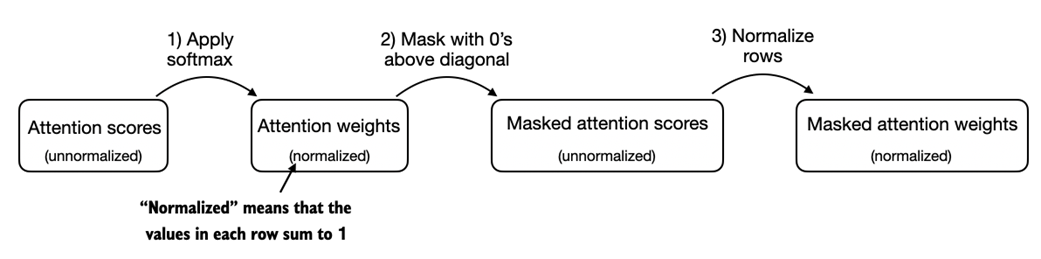


In [27]:
# 1. Apply Softmax on Attention Scores

queries= sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim = 1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [28]:
# 2. Mask with 0's above diagonal

context_length = attn_weights.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
# mask_simple
# attn_weight_masked = torch.tril(attn_weights)
attn_weight_masked = attn_weights * mask_simple
attn_weight_masked

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)

In [29]:
# 3. Renormalize attention weights

row_sums = attn_weight_masked.sum(dim=1, keepdim = True)
attn_weight_masked_norm = attn_weight_masked / row_sums
print(attn_weight_masked_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


# Applying Causal Attention - Efficient

## Instead of Applying Softmax (Normalizing) twice and Masking, 
## Same behaviour can be accomplished by Masking with -INF and then aplying softmax 

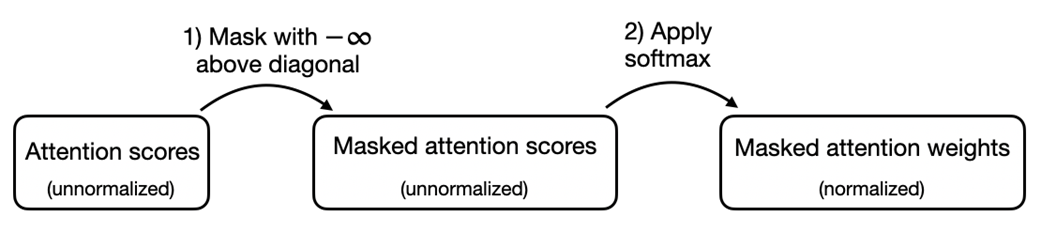

In [30]:
# Efficient Masking for Causal Attention

mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print(mask)
print(attn_scores)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])
tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackw

In [31]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [32]:
context_length = 6
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
mask.bool()

tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])

In [33]:
context_vec = attn_weights @ values
context_vec

tensor([[0.1855, 0.8812],
        [0.2795, 0.9361],
        [0.3133, 0.9508],
        [0.2994, 0.8595],
        [0.2702, 0.7554],
        [0.2772, 0.7618]], grad_fn=<MmBackward0>)

## Masking additional Attention Weights with Dropout

In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # dropout = 50 %
example = torch.ones(6, 6)
print(dropout(example))

### Why do the value shows 2?

```
To compensate for the reduction in active elements, 
the values of the remaining elements in the matrix are scaled up by a factor of 1/0.5 =2
This scaling is crucial to maintain the overall balance of the attention weights, 
ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phases.
```

In [ ]:
# apply dropout to the attention weight matrix
torch.manual_seed(123)
print(dropout(attn_weights))

## define batch

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)
print(batch)

## Implementing a compact causal attention class

In [ ]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False, iter=0):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
           'mask',
           torch.triu(torch.ones(context_length, context_length),
           diagonal=1)
        )
        print("iteration: ",iter)
        print("W_q_weights: ", self.W_query.state_dict()['weight'])
        # print("W_q_bias: ", self.W_query.state_dict()['bias'])
 
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
 
        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) 
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
 
        context_vec = attn_weights @ values
        return context_vec

## Class Explanation

This code defines a class `CausalAttention`, which is a custom PyTorch module implementing a causal self-attention mechanism. This type of attention is commonly used in language models, where each token can only attend to previous tokens, not future ones (hence "causal"). 

Let's break down the class and then go through the `forward` method line by line.

### Class Overview

1. **Initialization (`__init__` method):**
   - **`d_in`**: Dimensionality of the input embeddings.
   - **`d_out`**: Dimensionality of the output embeddings (usually the same as `d_in` in many models, but can be different).
   - **`context_length`**: The maximum number of tokens in the input sequence, used to create the causal mask.
   - **`dropout`**: Dropout rate for regularizing the attention weights.
   - **`qkv_bias`**: A boolean indicating whether to use a bias term in the linear projections for queries, keys, and values.

   The initialization sets up the linear transformations for the queries, keys, and values. It also initializes a dropout layer and creates a causal mask using `register_buffer` so that it's part of the module's state but isn't updated during training.

2. **Causal Mask**: The mask is a triangular matrix that prevents a token from attending to future tokens. The `torch.triu` function creates an upper triangular matrix filled with ones above the diagonal, and zeros elsewhere.

### `forward` Method Breakdown

The `forward` method implements the forward pass of the causal attention mechanism, taking a batch of input sequences and producing context-aware output embeddings.

```python
def forward(self, x):
```
- The `forward` method is called when a batch of input data `x` is passed through the model. `x` is expected to have the shape `(b, num_tokens, d_in)`, where:
  - `b` is the batch size.
  - `num_tokens` is the number of tokens in each sequence.
  - `d_in` is the dimensionality of each token's embedding.

```python
    b, num_tokens, d_in = x.shape
```
- Unpacks the shape of the input tensor `x`. `b` is the batch size, `num_tokens` is the number of tokens, and `d_in` is the input dimensionality (which should match the `d_in` given during initialization).

```python
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
```
- Applies linear transformations to the input `x` to obtain keys, queries, and values:
  - **Keys**: Represent the data against which the relevance of the queries will be measured.
  - **Queries**: Represent the data that will be compared to the keys to generate attention scores.
  - **Values**: Contain the actual information that will be weighted and combined based on the attention scores.

```python
    attn_scores = queries @ keys.transpose(1, 2)
```
- Computes the attention scores by performing a batch matrix multiplication of `queries` and the transpose of `keys`. This results in a score matrix of shape `(b, num_tokens, num_tokens)`, where each score represents the similarity between a query and a key. The transposition ensures that each query compares against every key.

```python
    attn_scores.masked_fill_(
        self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
```
- Applies the causal mask to the attention scores. The mask is of shape `(context_length, context_length)` but is sliced to match the number of tokens in the input sequence. This mask ensures that positions can only attend to previous positions (not future ones). The use of `-torch.inf` effectively nullifies the attention to masked positions, making them irrelevant when computing the softmax.

```python
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
```
- Normalizes the attention scores using the softmax function. The division by the square root of the key dimension (`keys.shape[-1]**0.5`) is a scaling factor that helps stabilize the gradients and improves convergence (a common practice in attention mechanisms). The result is a set of attention weights that sum to 1 across each row.

```python
    attn_weights = self.dropout(attn_weights)
```
- Applies dropout to the attention weights to prevent overfitting. This randomly zeros some of the attention weights during training, encouraging the model to not rely on any single position too much.

```python
    context_vec = attn_weights @ values
```
- Computes the context vectors by performing a weighted sum of the value vectors, using the attention weights as coefficients. This results in a new representation of each token, informed by the relevant tokens before it.

```python
    return context_vec
```
- Returns the context-aware output of shape `(b, num_tokens, d_out)`, where each token has been processed to attend to previous relevant tokens according to the causal attention mechanism.

### Summary

The `CausalAttention` class implements a basic building block of transformer models, specifically designed for scenarios where future tokens should not influence the current token's representation (e.g., autoregressive language modeling). The use of random dropout helps in regularizing the model, and the softmax normalization ensures that attention is distributed properly among relevant past tokens.



In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

# Extending single-head attention to multi-head attention

## A wrapper class to implement multi-head attention

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias, x) 
             for x in range(num_heads)]
        )
 
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
print(context_length)
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
 
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

## Implementing multi-head attention with weight splits - Efficient

In [4]:
%%writefile previous_chapters.py
import torch
import torch.nn as nn
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, 
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
 
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # print("W_q_weights: ", self.W_query.state_dict()['weight'])

        # output projection layer
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        
        self.register_buffer(
            'mask',
             torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
 
    def forward(self, x):

        # b is the batch size.
        # num_tokens is the number of tokens in each sequence.
        # d_in is the dimensionality of each token's embedding.
        
        
        b, num_tokens, d_in = x.shape
        # print(f"b: {b} | num_tokens: {num_tokens} | d_in: {d_in}")
        # Unpacks the shape of the input tensor x. b is the batch size, num_tokens is the number of tokens, 
        # and d_in is the input dimensionality (which should match the d_in given during initialization).

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # reshaping (b, num_tokens, self.d_out) to (b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # bring num_heads dimensions before num_tokens dimension
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Computes the attention scores by performing a batch matrix multiplication of queries and the transpose of keys. 
        # This results in a score matrix of shape (b, num_tokens, num_tokens), 
        # where each score represents the similarity between a query and a key. 
        # The transposition ensures that each query compares against every key.
        attn_scores = queries @ keys.transpose(2, 3)

        # Applies the causal mask to the attention scores. 
        # The mask is of shape (context_length, context_length) but is sliced to match the number of tokens in the input sequence. 
        # This mask ensures that positions can only attend to previous positions (not future ones). 
        # The use of -torch.inf effectively nullifies the attention to masked positions, 
        # making them irrelevant when computing the softmax.
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Normalizes the attention scores using the softmax function. 
        # The division by the square root of the key dimension (keys.shape[-1]**0.5) is a scaling factor 
        # that helps stabilize the gradients and improves convergence (a common practice in attention mechanisms). 
        # The result is a set of attention weights that sum to 1 across each row.
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)

        # Applies dropout to the attention weights to prevent overfitting. 
        # This randomly zeros some of the attention weights during training, 
        # encouraging the model to not rely on any single position too much.
        attn_weights = self.dropout(attn_weights)

        # Computes the context vectors by performing a weighted sum of the value vectors, using the attention weights as coefficients. 
        # This results in a new representation of each token, informed by the relevant tokens before it.
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Returns the context-aware output of shape (b, num_tokens, d_out), 
        # where each token has been processed to attend to previous relevant tokens according to the causal attention mechanism.
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec

Overwriting previous_chapters.py


In [ ]:
print(batch)
print(batch.shape)

In [ ]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch) # this line essentially invoke __call__ method, which inturn invokes the forward method
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

In [ ]:
context_length = 1024
d_in, d_out = 768, 768
num_heads = 12

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
# context_vecs = mha(batch)
# print(context_vecs)
# print("context_vecs.shape:", context_vecs.shape)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(mha)

## Understanding Math operations

In [ ]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],
                   
                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])
print(a.shape)

In [ ]:
print(a.T.shape)

In [ ]:
b=a.transpose(2,3)
print(b)
print(b.shape)

In [ ]:
print(a @ b)

In [ ]:
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)
 
second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)